1 2: 
Расстояние Евклида: 7.54983443527075
Квадрат Евклидова расстояния: 57.0
Расстояние Чебышева: 7.0
Расстояние Хемминга: 11.0
1 3: 
Расстояние Евклида: 6.0
Квадрат Евклидова расстояния: 36.0
Расстояние Чебышева: 6.0
Расстояние Хемминга: 6.0
1 4: 
Расстояние Евклида: 15.033296378372908
Квадрат Евклидова расстояния: 226.0
Расстояние Чебышева: 15.0
Расстояние Хемминга: 16.0
2 3: 
Расстояние Евклида: 3.0
Квадрат Евклидова расстояния: 9.0
Расстояние Чебышева: 2.0
Расстояние Хемминга: 5.0
2 4: 
Расстояние Евклида: 14.45683229480096
Квадрат Евклидова расстояния: 209.00000000000003
Расстояние Чебышева: 13.0
Расстояние Хемминга: 21.0
3 4: 
Расстояние Евклида: 15.811388300841896
Квадрат Евклидова расстояния: 250.0
Расстояние Чебышева: 15.0
Расстояние Хемминга: 20.0


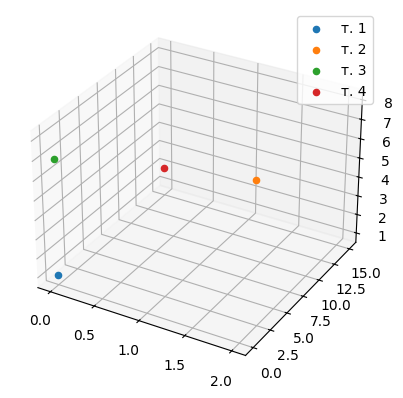

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

p1 = np.array([0,0,1])
p2 = np.array([2,2,8])
p3 = np.array([0,0,7])
p4 = np.array([0,15,2])

points = [p1,p2,p3,p4]

for i in range(4):
    for j in range(i + 1, 4):
        print(f"{i+1} {j+1}: ")
        print(f"Расстояние Евклида: {np.linalg.norm(points[i] - points[j])}")
        print(f"Квадрат Евклидова расстояния: {np.linalg.norm(points[i] - points[j])**2}")
        print(f"Расстояние Чебышева: {np.linalg.norm(points[i] - points[j], ord=np.inf)}")
        print(f"Расстояние Хемминга: {np.linalg.norm(points[i] - points[j], ord=1)}")

f = plt.figure()
a = f.add_subplot(111, projection='3d')
a.scatter(p1[0], p1[1], p1[2], label='т. 1')
a.scatter(p2[0], p2[1], p2[2], label='т. 2')
a.scatter(p3[0], p3[1], p3[2], label='т. 3')
a.scatter(p4[0], p4[1], p4[2], label='т. 4')
plt.legend()
plt.show()

In [ ]:
import numpy as np

matrix = np.arange(5)
matrix = np.tile(matrix, (5, 1))

print(matrix)

[[0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]]


Accuracy: 0.957


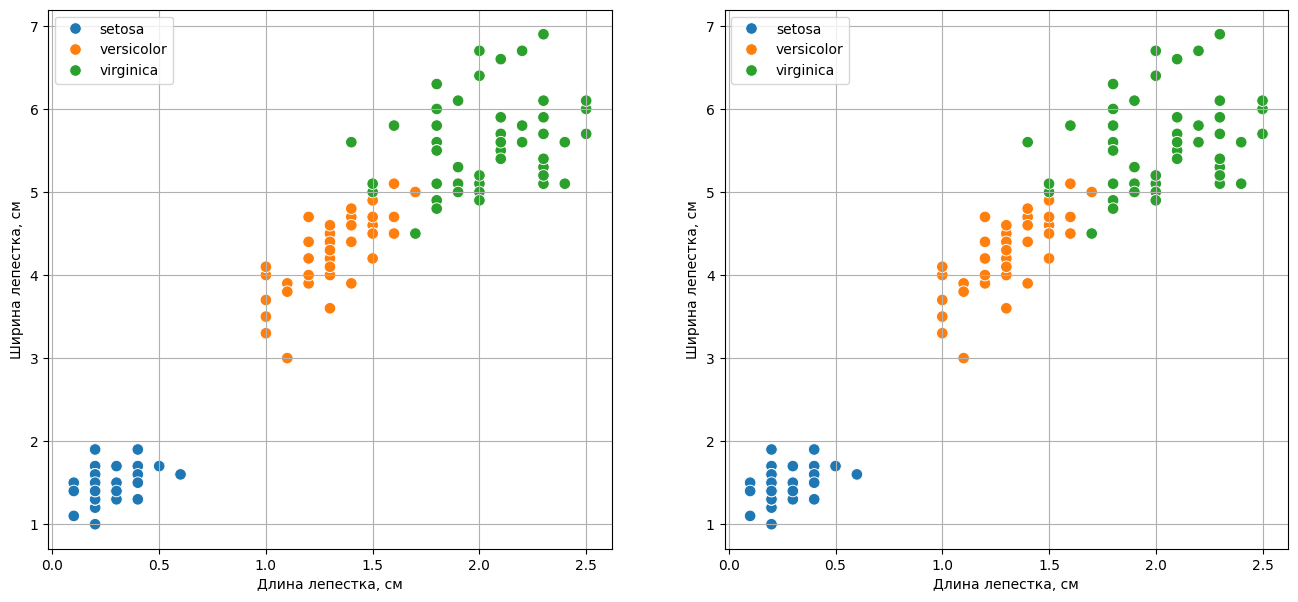

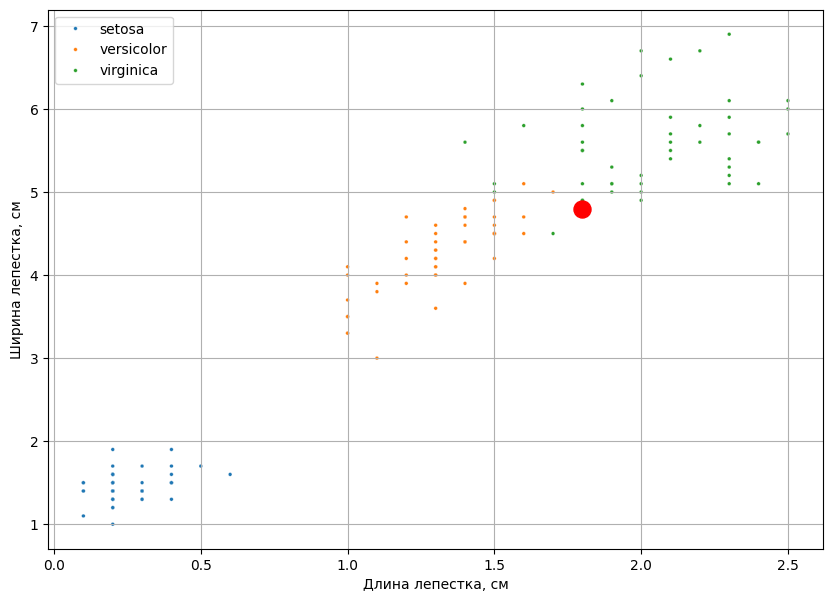

In [31]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
import seaborn as sns

iris = sns.load_dataset('iris')

plt.figure(figsize=(16, 7))
plt.subplot(121)
sns.scatterplot(
    data=iris,
    x='petal_width', y='petal_length',
    hue='species',
    s=70
)
plt.xlabel("Длина лепестка, см")
plt.ylabel("Ширина лепестка, см")
plt.legend()
plt.grid()

plt.subplot(122)
sns.scatterplot( data=iris,x='petal_width', y='petal_length',hue='species',s=70)
plt.xlabel("Длина лепестка, см")
plt.ylabel("Ширина лепестка, см")
plt.legend()
plt.grid()

x_train, x_test, y_train, y_test = train_test_split(
    iris.iloc[:, :-1],
    iris.iloc[:, -1],
    test_size=0.15 # размер тестовой выборки 15%
)

x_train.shape, x_test.shape, y_train.shape, y_test.shape
x_train.head()
y_train.head()

model = KNeighborsClassifier(n_neighbors=5) #ближайщие соседи
model.fit(x_train, y_train)


y_pred = model.predict(x_test)
y_pred

plt.figure(figsize=(10, 7))
sns.scatterplot(data=iris,x='petal_width', y='petal_length',hue='species',s=7)
plt.xlabel("Длина лепестка, см")
plt.ylabel("Ширина лепестка, см")
plt.legend(loc=2)
plt.grid()

for i in range(len(y_test)):
    if np.array(y_test)[i] != y_pred[i]:
        plt.scatter(x_test.iloc[i, 3], x_test.iloc[i, 2], color='red', s=150)


print(f'Accuracy: {accuracy_score(y_test, y_pred):.3f}')

# меньше тестирования -> обучения больше, но тестирование слабее

In [36]:
from sklearn.feature_extraction import DictVectorizer
data = [
    {"sex": "female", "eye": "brown", "height": 165, "weight": 55},
    {"sex": "male",   "eye": "blue",  "height": 180, "weight": 72},
    {"sex": "male",   "eye": "brown", "height": 175, "weight": 80},
    {"sex": "female", "eye": "green", "height": 170, "weight": 60}
]

dictVectorizer = DictVectorizer(sparse=False)
features = dictVectorizer.fit_transform(data)
features

array([[  0.,   1.,   0., 165.,   1.,   0.,  55.],
       [  1.,   0.,   0., 180.,   0.,   1.,  72.],
       [  0.,   1.,   0., 175.,   0.,   1.,  80.],
       [  0.,   0.,   1., 170.,   1.,   0.,  60.]])